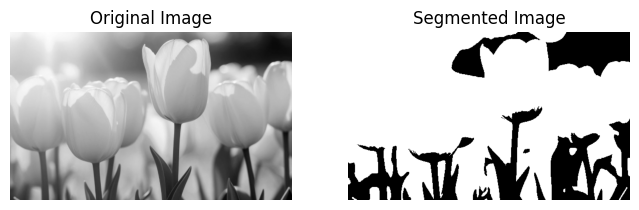

In [3]:
import cv2
from matplotlib import pyplot as plt

# Step 1: Load Image
image = cv2.imread("test.png")  # use your image
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 2: Apply Otsu Thresholding
_, thresh = cv2.threshold(gray, 0, 255, 
                          cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Step 3: Display Output
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(thresh, cmap='gray')
plt.title("Segmented Image")
plt.axis('off')

plt.show()

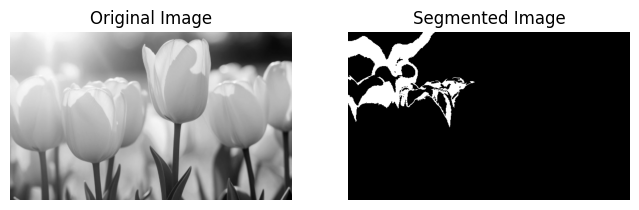

In [5]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Step 1: Load image
image = cv2.imread("test.png")  # use your image
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 2: Initialize
segmented = np.zeros_like(gray)
visited = np.zeros_like(gray, dtype=bool)

# Seed point (IMPORTANT - choose inside object)
seed = (100, 100)  # change depending on image

threshold = 10

# Step 3: Region Growing using stack
stack = [seed]

while stack:
    x, y = stack.pop()

    if visited[x, y]:
        continue

    visited[x, y] = True
    segmented[x, y] = 255

    # 8-connected neighbors
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            nx, ny = x + dx, y + dy

            if (0 <= nx < gray.shape[0] and 
                0 <= ny < gray.shape[1] and 
                not visited[nx, ny]):

                if abs(int(gray[nx, ny]) - int(gray[seed])) < threshold:
                    stack.append((nx, ny))

# Step 4: Display
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(segmented, cmap='gray')
plt.title("Segmented Image")
plt.axis('off')

plt.show()